# Decision Tree Regression Notebook

This notebook implements a **Decision Tree Regressor** to predict property transaction prices (`Tran_Pri`). The workflow is divided into logical stages, from data loading to model evaluation and visualisation.

# Decision Tree Regression – Simplified Workflow

1. **Load data** – training and test CSVs.
2. **Clean & engineer features** – convert dates, compute building age, parse elevator ratio, log‑transform area, create floor ratio, etc.
3. **Select features** – 11 numeric + 13 categorical.
4. **Handle missing values** – median for numeric, "Unknown" for categorical.
5. **One‑hot encode** categorical variables.
6. **Split** training data into 80% train / 20% validation.
7. **Tune hyperparameters** with grid search (max_depth, min_samples_split, min_samples_leaf) using 3‑fold CV and R² score.
8. **Evaluate best model** – compute MAE, RMSE, R² on train and validation.
9. **Plot results** – feature importance, actual vs predicted, residuals, grid search heatmaps, partial dependence plots, price‑band confusion matrix.
10. **Save outputs** – predictions, feature importance, summary, and figures.


In [2]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [4]:
# -------------------------
# 1. Load data
# -------------------------
"""
df_train = pd.read_csv('use--filtered_data_train_processed_features_all_columns.csv', encoding='latin1')
df_test = pd.read_csv('use--filtered_data_test_processed_features_all_columns.csv', encoding='latin1')

These csv files are the result of a data cleaning and processing step, then they are renamed and put to data folder:
use--filtered_data_train_processed_features_all_columns.csv = train.csv
use--filtered_data_test_processed_features_all_columns.csv = test.csv

"""

train_path = "../data/TRAIN.csv"
test_path = "../data/TEST.csv"

df_train = pd.read_csv(train_path, encoding='latin1')
df_test = pd.read_csv(test_path, encoding='latin1')

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)
print("\nTrain columns:")
print(df_train.columns.tolist())


Train shape: (165808, 23)
Test shape : (62733, 23)

Train columns:
['City', 'Reg', 'Dist', 'Neigh', 'Tran_Dt', 'Tran_Day', 'Tran_Pri', 'Layout', 'Prop_Flo', 'Tot_Flo', 'Flo_Area', 'Build_Type', 'Orient', 'Build_Yr', 'ReNov', 'Build_Str', 'EA_Ratio', 'Lift', 'Prop_Type', 'Build_Pur', 'Total_Rooms', 'Build_Yr_Filled', 'Elevator_Density']


In [3]:
# -------------------------
# 2. Copy data to protect the original DataFrames
# -------------------------
train = df_train.copy()
test = df_test.copy()

# -------------------------
# 3. Convert the target variable to numeric
# -------------------------
train['Tran_Pri'] = pd.to_numeric(train['Tran_Pri'], errors='coerce')

# Remove rows with missing or non-positive target values
train = train.dropna(subset=['Tran_Pri'])
train = train[train['Tran_Pri'] > 0]

print("\nAfter cleaning target, train shape:", train.shape)



After cleaning target, train shape: (165808, 23)


In [4]:
# -------------------------
# 4. Clean numeric fields
# -------------------------
train['Flo_Area'] = pd.to_numeric(train['Flo_Area'], errors='coerce')
test['Flo_Area'] = pd.to_numeric(test['Flo_Area'], errors='coerce')

train['Tot_Flo'] = pd.to_numeric(train['Tot_Flo'], errors='coerce')
test['Tot_Flo'] = pd.to_numeric(test['Tot_Flo'], errors='coerce')

# Convert Build_Yr to numeric; unknown values become NaN
train['Build_Yr_Num'] = pd.to_numeric(train['Build_Yr'], errors='coerce')
test['Build_Yr_Num'] = pd.to_numeric(test['Build_Yr'], errors='coerce')

# -------------------------
# 5. Date feature engineering
# -------------------------
train['Tran_Dt'] = pd.to_datetime(train['Tran_Dt'], errors='coerce')
test['Tran_Dt'] = pd.to_datetime(test['Tran_Dt'], errors='coerce')

train['Tran_Year'] = train['Tran_Dt'].dt.year
test['Tran_Year'] = test['Tran_Dt'].dt.year

train['Tran_Month'] = train['Tran_Dt'].dt.month
test['Tran_Month'] = test['Tran_Dt'].dt.month

train['Tran_Quarter'] = train['Tran_Dt'].dt.quarter
test['Tran_Quarter'] = test['Tran_Dt'].dt.quarter

# -------------------------
# 6. Building age feature
# -------------------------
train['Build_Age'] = train['Tran_Year'] - train['Build_Yr_Num']
test['Build_Age'] = test['Tran_Year'] - test['Build_Yr_Num']

# Prevent negative or clearly invalid ages
train.loc[train['Build_Age'] < 0, 'Build_Age'] = np.nan
test.loc[test['Build_Age'] < 0, 'Build_Age'] = np.nan


In [5]:
# -------------------------
# 7. Parse elevator-to-apartment ratio
# Example: 1E2A -> 1/2 = 0.5
# -------------------------
def parse_ea_ratio(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    match = re.match(r'(\d+)E(\d+)A', x)
    if match:
        elevators = float(match.group(1))
        apartments = float(match.group(2))
        if apartments != 0:
            return elevators / apartments
    return np.nan

train['EA_Ratio_Num'] = train['EA_Ratio'].apply(parse_ea_ratio)
test['EA_Ratio_Num'] = test['EA_Ratio'].apply(parse_ea_ratio)

# -------------------------
# 8. Relative floor-level features
# -------------------------
floor_map = {
    'Lower floor': 1,
    'Middle floor': 2,
    'Upper floor': 3
}

train['Prop_Flo_Level'] = train['Prop_Flo'].map(floor_map)
test['Prop_Flo_Level'] = test['Prop_Flo'].map(floor_map)

train['Floor_Ratio'] = train['Prop_Flo_Level'] / train['Tot_Flo']
test['Floor_Ratio'] = test['Prop_Flo_Level'] / test['Tot_Flo']

# Replace invalid infinite values
train['Floor_Ratio'] = train['Floor_Ratio'].replace([np.inf, -np.inf], np.nan)
test['Floor_Ratio'] = test['Floor_Ratio'].replace([np.inf, -np.inf], np.nan)

# -------------------------
# 9. Log-transformed floor area
# -------------------------
train['Log_Flo_Area'] = np.log1p(train['Flo_Area'])
test['Log_Flo_Area'] = np.log1p(test['Flo_Area'])


In [6]:
# -------------------------
# 10. Select final features
# -------------------------
numeric_features = [
    'Tot_Flo',
    'Flo_Area',
    'Build_Yr_Num',
    'Tran_Year',
    'Tran_Month',
    'Tran_Quarter',
    'Build_Age',
    'EA_Ratio_Num',
    'Prop_Flo_Level',
    'Floor_Ratio',
    'Log_Flo_Area'
]

categorical_features = [
    'City',
    'Reg',
    'Dist',
    'Neigh',
    'Layout',
    'Prop_Flo',
    'Build_Type',
    'Orient',
    'ReNov',
    'Build_Str',
    'Lift',
    'Prop_Type',
    'Build_Pur'
]

target = 'Tran_Pri'
selected_features = numeric_features + categorical_features

print("\nSelected features:")
print(selected_features)

# -------------------------
# 11. Extract X and y
# -------------------------
X_train = train[selected_features].copy()
y_train = train[target].copy()
X_test = test[selected_features].copy()



Selected features:
['Tot_Flo', 'Flo_Area', 'Build_Yr_Num', 'Tran_Year', 'Tran_Month', 'Tran_Quarter', 'Build_Age', 'EA_Ratio_Num', 'Prop_Flo_Level', 'Floor_Ratio', 'Log_Flo_Area', 'City', 'Reg', 'Dist', 'Neigh', 'Layout', 'Prop_Flo', 'Build_Type', 'Orient', 'ReNov', 'Build_Str', 'Lift', 'Prop_Type', 'Build_Pur']


In [7]:
# -------------------------
# 12. Handle missing values
# Decision trees cannot accept NaN directly,
# so simple imputation is applied first
# Numeric -> median
# Categorical -> 'Unknown'
# -------------------------
for col in numeric_features:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

for col in categorical_features:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

# -------------------------
# 13. One-hot encode categorical variables
# -------------------------
X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Align training and test columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("\nEncoded X_train shape:", X_train.shape)
print("Encoded X_test shape :", X_test.shape)
print("\nFirst 10 columns of X_train:")
print(X_train.columns[:10].tolist())
print("\nTarget summary:")
print(y_train.describe())



Encoded X_train shape: (165808, 13246)
Encoded X_test shape : (62733, 13246)

First 10 columns of X_train:
['Tot_Flo', 'Flo_Area', 'Build_Yr_Num', 'Tran_Year', 'Tran_Month', 'Tran_Quarter', 'Build_Age', 'EA_Ratio_Num', 'Prop_Flo_Level', 'Floor_Ratio']

Target summary:
count    165808.000000
mean       2322.409238
std        1628.105281
min          10.000000
25%        1350.000000
50%        1990.000000
75%        2810.000000
max       45000.000000
Name: Tran_Pri, dtype: float64


In [8]:
# -------------------------
# 14. Optionally save processed data
# -------------------------
X_train.to_csv('dt_X_train_ready.csv', index=False)
X_test.to_csv('dt_X_test_ready.csv', index=False)
y_train.to_csv('dt_y_train_ready.csv', index=False)

print("\nFeature engineering and encoding completed successfully.")



Feature engineering and encoding completed successfully.


In [9]:
# -------------------------
# 15. Split training and validation sets
# -------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

print("\nTrain split:", X_tr.shape, y_tr.shape)
print("Val split  :", X_val.shape, y_val.shape)

# -------------------------
# 16. Reduce memory usage
# Convert to float32 NumPy arrays
# -------------------------
X_tr_np = X_tr.astype(np.float32).to_numpy()
X_val_np = X_val.astype(np.float32).to_numpy()
X_test_np = X_test.astype(np.float32).to_numpy()

y_tr_np = y_tr.to_numpy()
y_val_np = y_val.to_numpy()

feature_names = X_tr.columns

print("\nConverted to NumPy arrays.")
print("X_tr_np shape:", X_tr_np.shape)
print("X_val_np shape:", X_val_np.shape)
print("X_test_np shape:", X_test_np.shape)



Train split: (132646, 13246) (132646,)
Val split  : (33162, 13246) (33162,)

Converted to NumPy arrays.
X_tr_np shape: (132646, 13246)
X_val_np shape: (33162, 13246)
X_test_np shape: (62733, 13246)


In [10]:
# -------------------------
# 17. Define evaluation function
# -------------------------
def evaluate_regression(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Performance:")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")

    return {
        "Dataset": dataset_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# -------------------------
# 18. Define a smaller memory-safe parameter grid
# -------------------------
param_grid = {
    'max_depth': [10, 15],
    'min_samples_split': [200, 500],
    'min_samples_leaf': [50, 100]
}

# -------------------------
# 19. Define the base model
# -------------------------
base_dt = DecisionTreeRegressor(
    criterion='squared_error',
    random_state=42
)

# -------------------------
# 20. Run grid search
# Use n_jobs=1 to avoid memory spikes from parallel copies
# -------------------------
print("\nStarting memory-safe GridSearchCV...")
start_time = time.time()

grid_search = GridSearchCV(
    estimator=base_dt,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_tr_np, y_tr_np)

end_time = time.time()
print(f"\nGrid search completed in {(end_time - start_time)/60:.2f} minutes.")



Starting memory-safe GridSearchCV...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END max_depth=10, min_samples_leaf=50, min_samples_split=200; total time= 2.7min
[CV] END max_depth=10, min_samples_leaf=50, min_samples_split=200; total time= 2.6min
[CV] END max_depth=10, min_samples_leaf=50, min_samples_split=200; total time= 2.6min
[CV] END max_depth=10, min_samples_leaf=50, min_samples_split=500; total time= 2.6min
[CV] END max_depth=10, min_samples_leaf=50, min_samples_split=500; total time= 2.6min
[CV] END max_depth=10, min_samples_leaf=50, min_samples_split=500; total time= 2.6min
[CV] END max_depth=10, min_samples_leaf=100, min_samples_split=200; total time= 2.6min
[CV] END max_depth=10, min_samples_leaf=100, min_samples_split=200; total time= 2.5min
[CV] END max_depth=10, min_samples_leaf=100, min_samples_split=200; total time=25.1min
[CV] END max_depth=10, min_samples_leaf=100, min_samples_split=500; total time= 3.0min
[CV] END max_depth=10, min_samples_lea

In [11]:
# -------------------------
# 21. Show best parameters and best cross-validation score
# -------------------------
print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV R2 Score:")
print(f"{grid_search.best_score_:.4f}")

# -------------------------
# 22. Extract the best model
# -------------------------
best_dt = grid_search.best_estimator_

# -------------------------
# 23. Predict on the training and validation sets
# -------------------------
y_tr_pred_best = best_dt.predict(X_tr_np)
y_val_pred_best = best_dt.predict(X_val_np)

# -------------------------
# 24. Evaluate the best model
# -------------------------
train_result = evaluate_regression(y_tr_np, y_tr_pred_best, "Train (Best DT)")
val_result = evaluate_regression(y_val_np, y_val_pred_best, "Validation (Best DT)")



Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 50, 'min_samples_split': 200}

Best CV R2 Score:
0.6911

Train (Best DT) Performance:
MAE : 499.6527
RMSE: 848.1135
R2  : 0.7288

Validation (Best DT) Performance:
MAE : 507.6448
RMSE: 853.6807
R2  : 0.7246


In [12]:
# -------------------------
# 25. Save and display grid search results
# -------------------------
cv_results = pd.DataFrame(grid_search.cv_results_)

results_table = cv_results[[
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'rank_test_score'
]].sort_values(by='rank_test_score')

print("\nAll Grid Search Results:")
display(results_table)

results_table.to_csv('dt_grid_search_results.csv', index=False)

# -------------------------
# 26. Feature importance
# -------------------------
feature_importance = best_dt.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print("\nTop 20 Feature Importances (Best DT):")
display(importance_df.head(20))

importance_df.to_csv('dt_feature_importance_best.csv', index=False)

# -------------------------
# 27. Predict on the test set
# -------------------------
test_pred = best_dt.predict(X_test_np)

test_prediction_df = pd.DataFrame({
    'Predicted_Tran_Pri': test_pred
})

test_prediction_df.to_csv('dt_test_predictions.csv', index=False)
print("\nTest predictions file saved: dt_test_predictions.csv")

# -------------------------
# 28. Save a best-model summary
# -------------------------
summary_df = pd.DataFrame([
    {
        'Best_Params': str(grid_search.best_params_),
        'Best_CV_R2': grid_search.best_score_,
        'Train_MAE': train_result['MAE'],
        'Train_RMSE': train_result['RMSE'],
        'Train_R2': train_result['R2'],
        'Val_MAE': val_result['MAE'],
        'Val_RMSE': val_result['RMSE'],
        'Val_R2': val_result['R2']
    }
])

display(summary_df)

summary_df.to_csv('dt_best_model_summary.csv', index=False)

print("\nBest model summary saved: dt_best_model_summary.csv")
print("\nDecision Tree grid search and evaluation completed successfully.")



All Grid Search Results:


,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score,mean_train_score,rank_test_score
4,15,200,50,0.691098,0.009779,0.703067,1
6,15,200,100,0.675857,0.009758,0.687095,2
5,15,500,50,0.660435,0.010365,0.666878,3
7,15,500,100,0.654026,0.009546,0.660566,4
0,10,200,50,0.631951,0.008698,0.641050,5
2,10,200,100,0.619953,0.009172,0.629281,6
1,10,500,50,0.608091,0.009972,0.613185,7
3,10,500,100,0.602433,0.009279,0.608013,8



Top 20 Feature Importances (Best DT):


,Feature,Importance
1,Flo_Area,0.472900
69,Reg_Xihu,0.084230
3,Tran_Year,0.066572
59,Reg_Shangcheng,0.059857
20,Reg_Binjiang,0.039322
29,Reg_Gongshu,0.034389
7,EA_Ratio_Num,0.029470
0,Tot_Flo,0.024182
10,Log_Flo_Area,0.023236
72,Reg_Yinzhouqu,0.019955



Test predictions file saved: dt_test_predictions.csv


,Best_Params,Best_CV_R2,Train_MAE,Train_RMSE,Train_R2,Val_MAE,Val_RMSE,Val_R2
0,"{'max_depth': 15, 'min_samples_leaf': 50, 'min...",0.691098,499.652747,848.113497,0.728759,507.644768,853.680719,0.724579



Best model summary saved: dt_best_model_summary.csv

Decision Tree grid search and evaluation completed successfully.


In [13]:
# -------------------------
# 29. Plot settings
# -------------------------
plt.rcParams['axes.unicode_minus'] = False


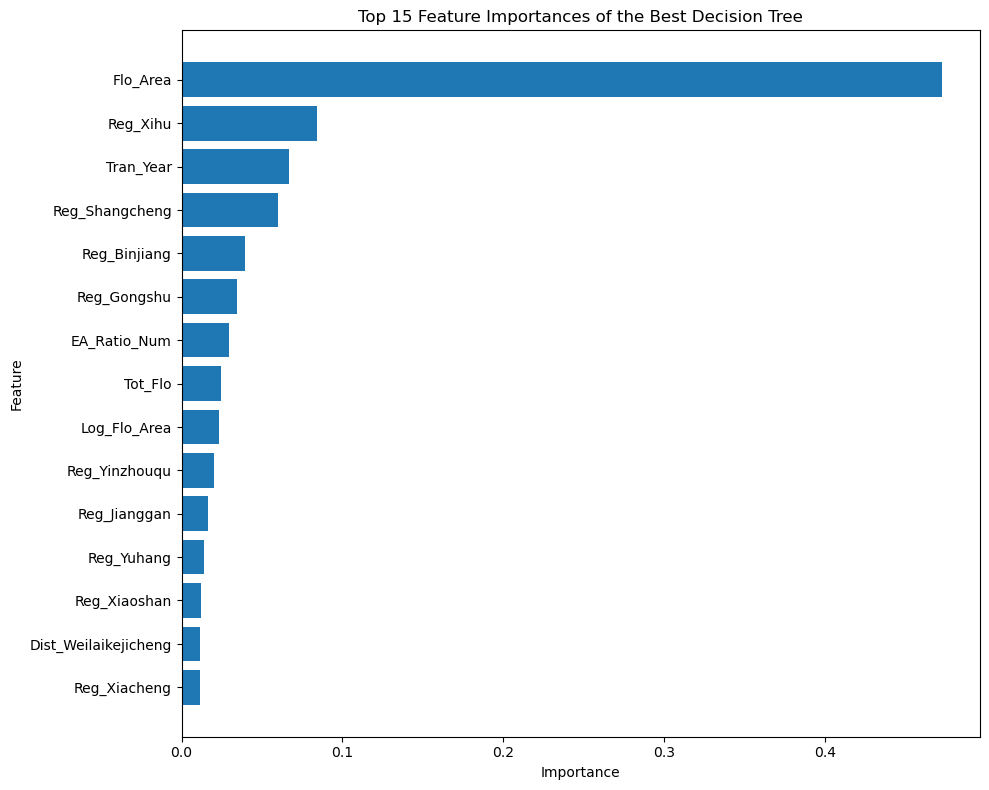

In [14]:
# -------------------------
# A. Top 15 feature importance bar chart
# -------------------------
top_n = 15
top_importance = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_importance['Feature'], top_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances of the Best Decision Tree')
plt.tight_layout()
plt.savefig('fig_feature_importance_top15.png', dpi=300, bbox_inches='tight')
plt.show()


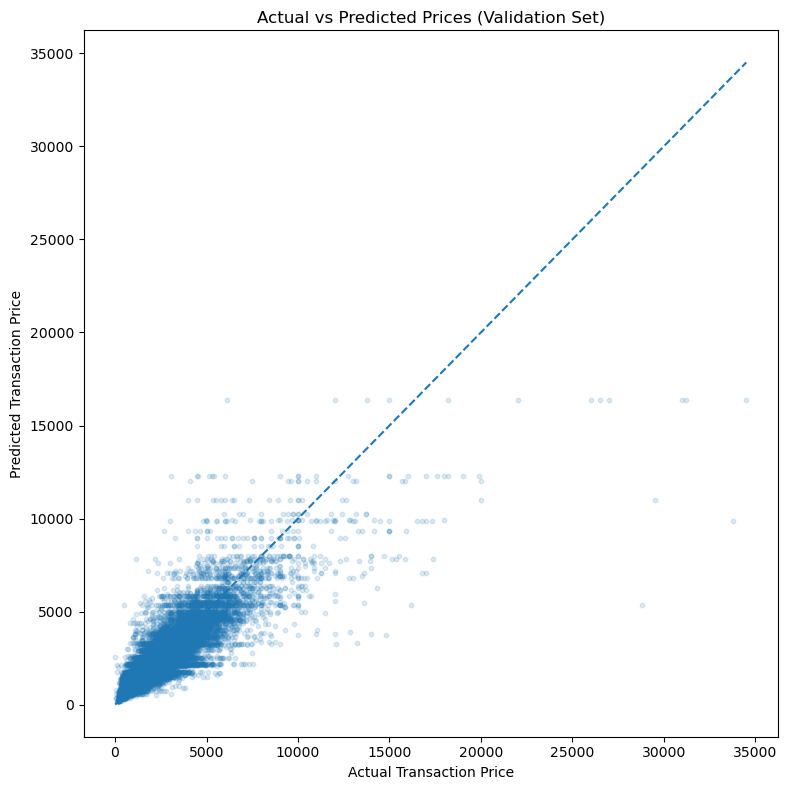

In [15]:
# -------------------------
# B. Actual vs predicted scatter plot
# -------------------------
plt.figure(figsize=(8, 8))
plt.scatter(y_val_np, y_val_pred_best, alpha=0.15, s=10)

min_val = min(y_val_np.min(), y_val_pred_best.min())
max_val = max(y_val_np.max(), y_val_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel('Actual Transaction Price')
plt.ylabel('Predicted Transaction Price')
plt.title('Actual vs Predicted Prices (Validation Set)')
plt.tight_layout()
plt.savefig('fig_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()


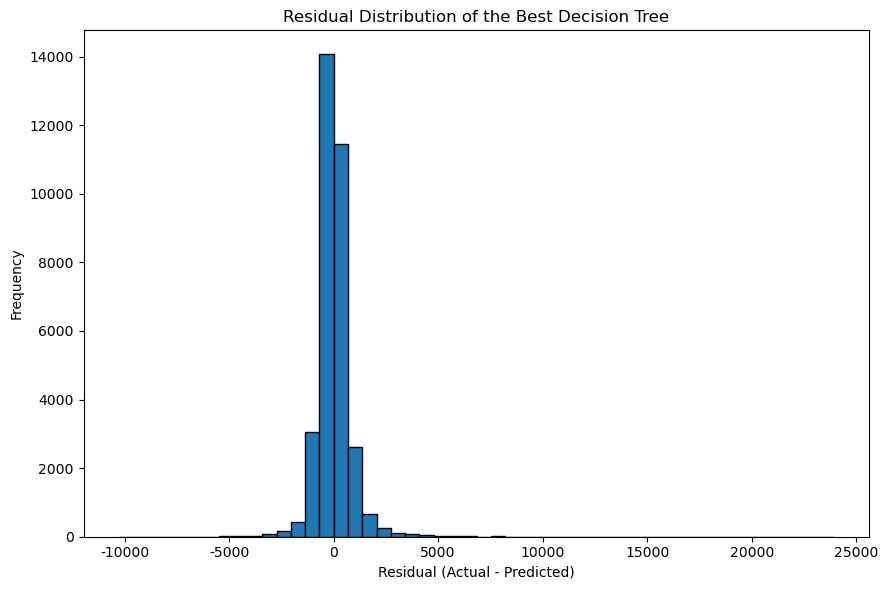

In [16]:
# -------------------------
# C. Residual distribution
# Residual = actual - predicted
# -------------------------
residuals = y_val_np - y_val_pred_best

plt.figure(figsize=(9, 6))
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Residual Distribution of the Best Decision Tree')
plt.tight_layout()
plt.savefig('fig_residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


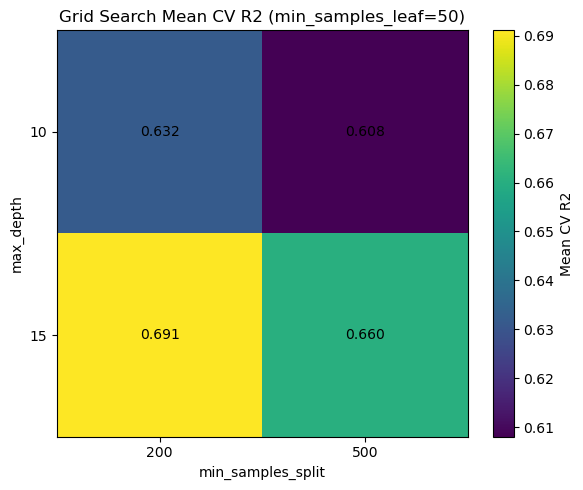

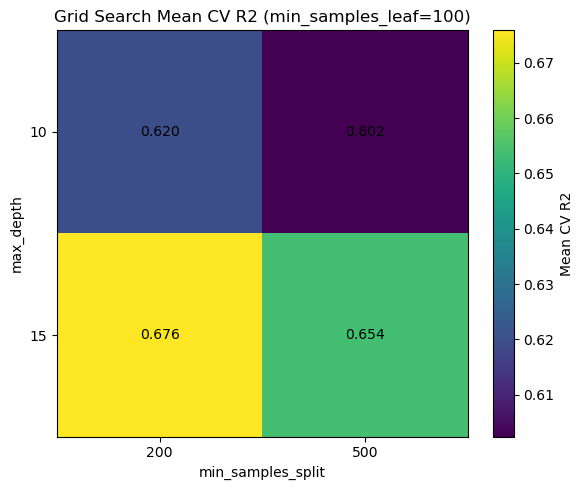

In [17]:
# -------------------------
# D. Grid search heatmaps
# One heatmap for each min_samples_leaf value
# -------------------------
leaf_values = sorted(results_table['param_min_samples_leaf'].astype(int).unique())

for leaf in leaf_values:
    subset = results_table.copy()
    subset['param_max_depth'] = subset['param_max_depth'].astype(int)
    subset['param_min_samples_split'] = subset['param_min_samples_split'].astype(int)
    subset['param_min_samples_leaf'] = subset['param_min_samples_leaf'].astype(int)

    subset_leaf = subset[subset['param_min_samples_leaf'] == leaf]

    heatmap_data = subset_leaf.pivot(
        index='param_max_depth',
        columns='param_min_samples_split',
        values='mean_test_score'
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(heatmap_data, aspect='auto')
    plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
    plt.xlabel('min_samples_split')
    plt.ylabel('max_depth')
    plt.title(f'Grid Search Mean CV R2 (min_samples_leaf={leaf})')

    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            value = heatmap_data.iloc[i, j]
            plt.text(j, i, f"{value:.3f}", ha='center', va='center')

    plt.colorbar(label='Mean CV R2')
    plt.tight_layout()
    plt.savefig(f'fig_gridsearch_heatmap_leaf_{leaf}.png', dpi=300, bbox_inches='tight')
    plt.show()


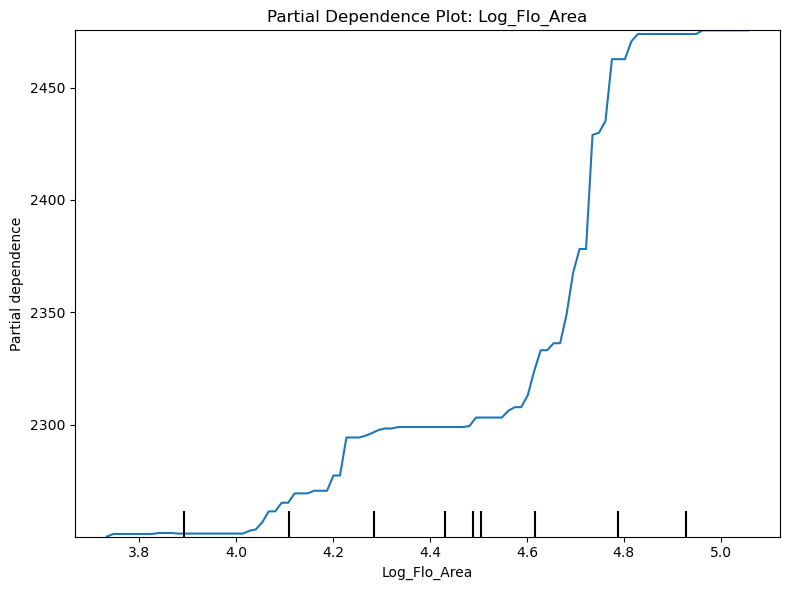

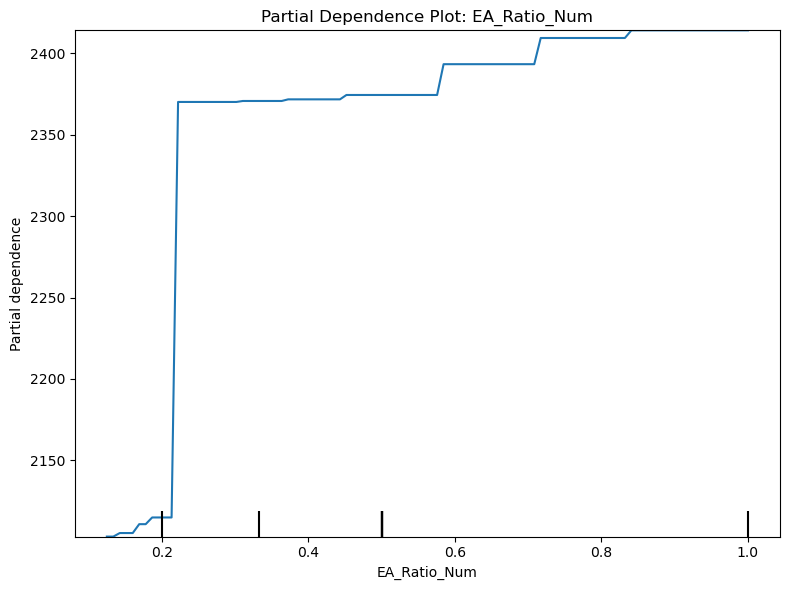

In [18]:
# -------------------------
# E. Partial dependence plots for selected features
# -------------------------
feature_name_to_index = {name: idx for idx, name in enumerate(feature_names)}
pdp_features = ['Log_Flo_Area', 'EA_Ratio_Num']

for feat in pdp_features:
    feat_idx = feature_name_to_index[feat]

    fig, ax = plt.subplots(figsize=(8, 6))
    PartialDependenceDisplay.from_estimator(
        best_dt,
        X_val_np,
        [feat_idx],
        feature_names=feature_names,
        ax=ax
    )
    plt.title(f'Partial Dependence Plot: {feat}')
    plt.tight_layout()
    plt.savefig(f'fig_pdp_{feat}.png', dpi=300, bbox_inches='tight')
    plt.show()


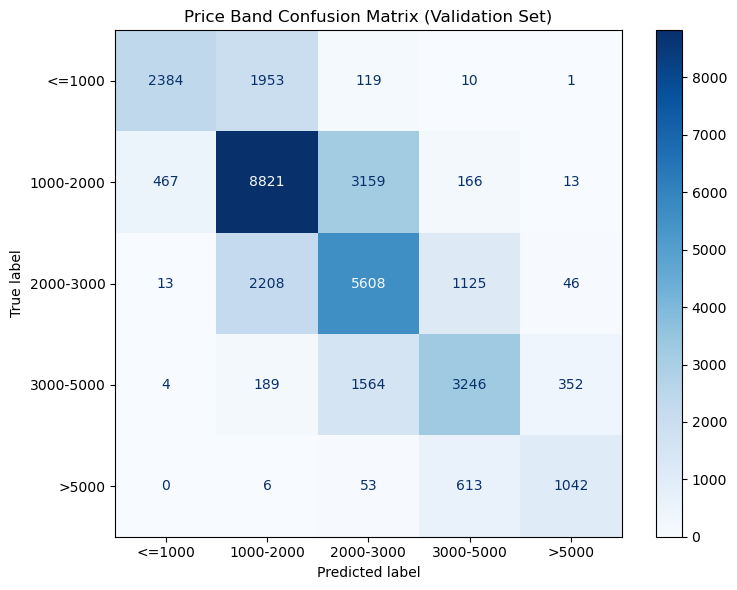

In [19]:
# -------------------------
# F. Price band confusion-matrix-style plot
# This is not a standard regression confusion matrix.
# It is a price-band visualization for reporting purposes.
# -------------------------
bins = [0, 1000, 2000, 3000, 5000, np.inf]
labels = ['<=1000', '1000-2000', '2000-3000', '3000-5000', '>5000']

y_val_actual_band = pd.cut(y_val_np, bins=bins, labels=labels, include_lowest=True)
y_val_pred_band = pd.cut(y_val_pred_best, bins=bins, labels=labels, include_lowest=True)

cm = confusion_matrix(y_val_actual_band, y_val_pred_band, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Price Band Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.savefig('fig_price_band_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


In [20]:
# -------------------------
# G. Save a figure log for reporting
# -------------------------
figure_log = pd.DataFrame({
    'Figure_File': [
        'fig_feature_importance_top15.png',
        'fig_actual_vs_predicted.png',
        'fig_residual_distribution.png',
        'fig_gridsearch_heatmap_leaf_50.png',
        'fig_gridsearch_heatmap_leaf_100.png',
        'fig_pdp_Log_Flo_Area.png',
        'fig_pdp_EA_Ratio_Num.png',
        'fig_price_band_confusion_matrix.png'
    ],
    'Description': [
        'Top 15 feature importances of the best decision tree model',
        'Scatter plot of actual vs predicted prices on validation set',
        'Histogram of residuals on validation set',
        'Grid search heatmap for min_samples_leaf=50',
        'Grid search heatmap for min_samples_leaf=100',
        'Partial dependence plot for Log_Flo_Area',
        'Partial dependence plot for EA_Ratio_Num',
        'Confusion-matrix-style chart using price bands'
    ]
})

display(figure_log)

figure_log.to_csv('dt_figure_log.csv', index=False)
print("\nAll figures have been generated and saved successfully.")


,Figure_File,Description
0,fig_feature_importance_top15.png,Top 15 feature importances of the best decisio...
1,fig_actual_vs_predicted.png,Scatter plot of actual vs predicted prices on ...
2,fig_residual_distribution.png,Histogram of residuals on validation set
3,fig_gridsearch_heatmap_leaf_50.png,Grid search heatmap for min_samples_leaf=50
4,fig_gridsearch_heatmap_leaf_100.png,Grid search heatmap for min_samples_leaf=100
5,fig_pdp_Log_Flo_Area.png,Partial dependence plot for Log_Flo_Area
6,fig_pdp_EA_Ratio_Num.png,Partial dependence plot for EA_Ratio_Num
7,fig_price_band_confusion_matrix.png,Confusion-matrix-style chart using price bands



All figures have been generated and saved successfully.
